# SciPy + Spotify

Praticando o uso das principais funções de `scipy.stats`, `scipy.optimize`, `scipy.linalg` e `scipy.signal`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats, linalg, optimize, signal

import kagglehub
import kagglehub as _kh
_kh.dataset_download = lambda *a, **kw: r'C:\Users\leonardo.flores\.cache\kagglehub\datasets\maharshipandya\-spotify-tracks-dataset\versions\1'
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
df = pd.read_csv(path+"/dataset.csv")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\leonardo.flores\.cache\kagglehub\datasets\maharshipandya\-spotify-tracks-dataset\versions\1


C:\Users\leonardo.flores\Desktop\UFOP\PROGRAMAÇÃO PARA CIÊNCIA DE DADOS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Análise Estatística com scipy.stats

Utilizando os atributos popularity, energy, danceability, valence e tempo, aplique funções do módulo scipy.stats para realizar uma análise estatística da base. Calcule medidas descritivas, ajuste uma distribuição normal à variável de popularidade, avalie a correlação entre atributos, compare grupos de músicas utilizando testes estatísticos e estime um intervalo de confiança por bootstrap. Apresente os resultados por meio de visualizações adequadas.

### Funções obrigatórias

- stats.norm.fit()
- stats.norm.pdf()
- stats.pearsonr()
- stats.ttest_ind()
- stats.bootstrap()


=== Medidas Descritivas ===
       popularity     energy  danceability    valence      tempo
count   32833.000  32833.000     32833.000  32833.000  32833.000
mean       42.477      0.699         0.655      0.511    120.881
std        24.984      0.181         0.145      0.233     26.904
min         0.000      0.000         0.000      0.000      0.000
25%        24.000      0.581         0.563      0.331     99.960
50%        45.000      0.721         0.672      0.512    121.984
75%        62.000      0.840         0.761      0.693    133.918
max       100.000      1.000         0.983      0.991    239.440

=== Ajuste Normal - Popularidade ===
Média ajustada: 42.48 | Desvio padrão ajustado: 24.98


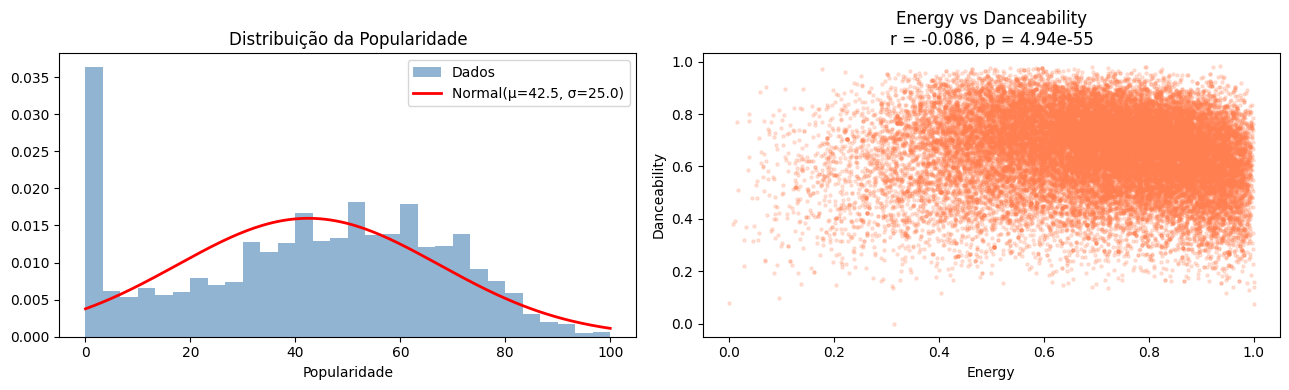


=== Correlação de Pearson: Energy x Danceability ===
r = -0.0861 | p-value = 4.9378e-55

=== Teste t: Energy (alta vs baixa popularidade) ===
t = -16.5958 | p-value = 1.3331e-61

=== Bootstrap IC 95% para Média da Popularidade ===
Intervalo: [39.27, 43.43]


In [2]:
atributos = ['popularity', 'energy', 'danceability', 'valence', 'tempo']
dados = df[atributos].dropna()

print("=== Medidas Descritivas ===")
print(dados.describe().round(3))

mu, std = stats.norm.fit(dados['popularity'])
print(f"\n=== Ajuste Normal - Popularidade ===")
print(f"Média ajustada: {mu:.2f} | Desvio padrão ajustado: {std:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.linspace(dados['popularity'].min(), dados['popularity'].max(), 200)
axes[0].hist(dados['popularity'], bins=30, density=True, alpha=0.6, color='steelblue', label='Dados')
axes[0].plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label=f'Normal(μ={mu:.1f}, σ={std:.1f})')
axes[0].set_title('Distribuição da Popularidade')
axes[0].set_xlabel('Popularidade')
axes[0].legend()

r, p = stats.pearsonr(dados['energy'], dados['danceability'])
axes[1].scatter(dados['energy'], dados['danceability'], alpha=0.2, s=5, color='coral')
axes[1].set_title(f'Energy vs Danceability\nr = {r:.3f}, p = {p:.2e}')
axes[1].set_xlabel('Energy')
axes[1].set_ylabel('Danceability')

plt.tight_layout()
plt.show()

print(f"\n=== Correlação de Pearson: Energy x Danceability ===")
print(f"r = {r:.4f} | p-value = {p:.4e}")

alta = dados[dados['popularity'] >= dados['popularity'].median()]['energy']
baixa = dados[dados['popularity'] < dados['popularity'].median()]['energy']
t_stat, p_val = stats.ttest_ind(alta, baixa)
print(f"\n=== Teste t: Energy (alta vs baixa popularidade) ===")
print(f"t = {t_stat:.4f} | p-value = {p_val:.4e}")

amostra = dados['popularity'].sample(500, random_state=42).to_numpy()
resultado_boot = stats.bootstrap((amostra,), np.mean, n_resamples=1000, confidence_level=0.95, random_state=42)
ic_low, ic_high = resultado_boot.confidence_interval
print(f"\n=== Bootstrap IC 95% para Média da Popularidade ===")
print(f"Intervalo: [{ic_low:.2f}, {ic_high:.2f}]")

## 2) Ajuste de Modelo com scipy.optimize

Considere que a popularidade de uma música pode ser estimada a partir do atributo energy. Construa uma função de erro baseada no erro quadrático médio (MSE) e utilize scipy.optimize para encontrar os parâmetros de um modelo linear que minimizem esse erro. Apresente os coeficientes encontrados e visualize os resultados.

### Função obrigatória

- optimize.minimize()


=== Modelo Linear: popularidade = a * energy + b ===
a (coeficiente angular): -15.0685
b (intercepto):          53.0043
MSE mínimo:              616.7538


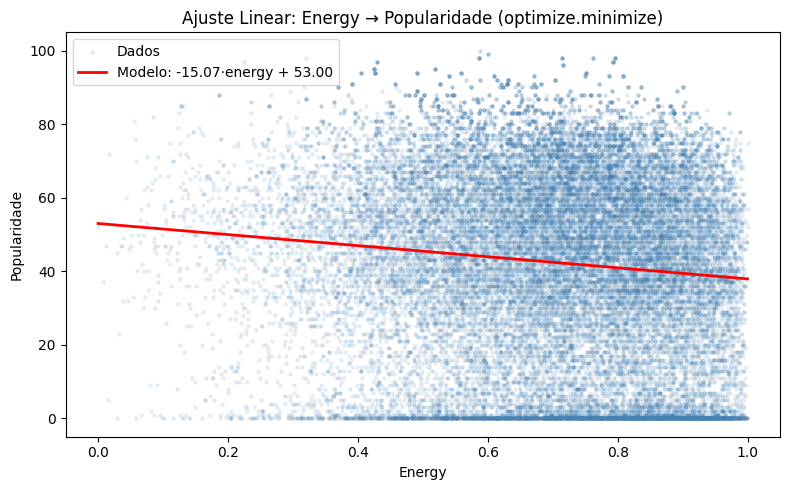

In [3]:
dados_opt = df[['energy', 'popularity']].dropna()
x = dados_opt['energy'].to_numpy()
y = dados_opt['popularity'].to_numpy()

def mse(params):
    a, b = params
    y_pred = a * x + b
    return np.mean((y - y_pred) ** 2)

resultado = optimize.minimize(mse, x0=[0.0, 0.0], method='BFGS')
a_opt, b_opt = resultado.x

print(f"=== Modelo Linear: popularidade = a * energy + b ===")
print(f"a (coeficiente angular): {a_opt:.4f}")
print(f"b (intercepto):          {b_opt:.4f}")
print(f"MSE mínimo:              {resultado.fun:.4f}")

x_line = np.linspace(x.min(), x.max(), 200)
y_line = a_opt * x_line + b_opt

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.1, s=5, color='steelblue', label='Dados')
plt.plot(x_line, y_line, 'r-', lw=2, label=f'Modelo: {a_opt:.2f}·energy + {b_opt:.2f}')
plt.title('Ajuste Linear: Energy → Popularidade (optimize.minimize)')
plt.xlabel('Energy')
plt.ylabel('Popularidade')
plt.legend()
plt.tight_layout()
plt.show()

# 3) Álgebra Linear com scipy.linalg
Utilizando os atributos danceability, energy, valence e tempo, padronize os dados, calcule a matriz de covariância, obtenha autovalores e autovetores, realize a decomposição SVD e apresente os principais resultados por meio de visualizações.

### Funções obrigatórias

- stats.zscore()
- np.cov()
- linalg.eigh()
- linalg.svd()


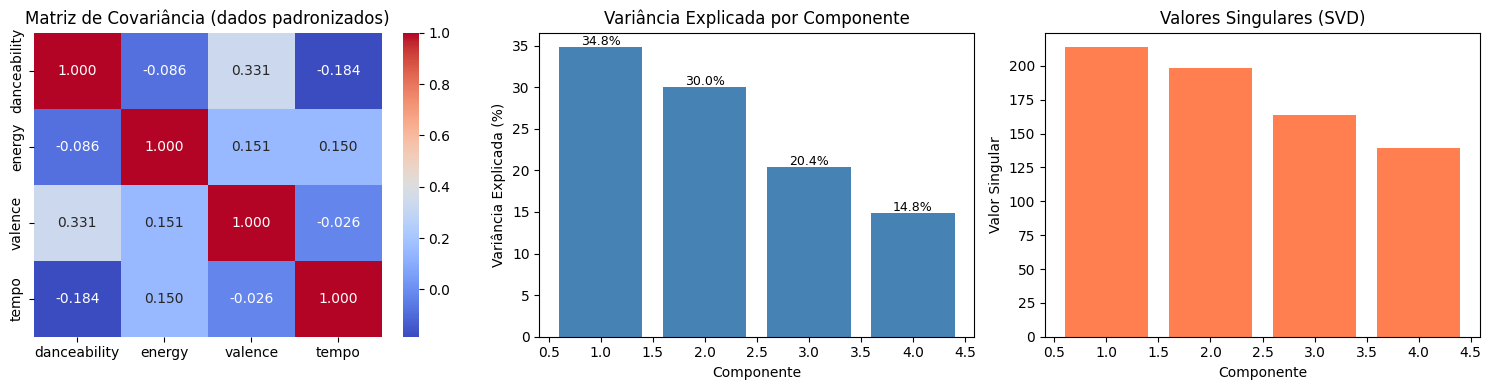

=== Autovalores ===
  Componente 1: autovalor = 1.3915 | variância explicada = 34.8%
  Componente 2: autovalor = 1.2003 | variância explicada = 30.0%
  Componente 3: autovalor = 0.8152 | variância explicada = 20.4%
  Componente 4: autovalor = 0.5932 | variância explicada = 14.8%

=== Autovetores (colunas) ===
                 PC1     PC2     PC3     PC4
danceability  0.7004 -0.0159  0.2607  0.6643
energy       -0.0803  0.7311 -0.5897  0.3336
valence       0.5866  0.4608  0.1210 -0.6549
tempo        -0.3987  0.5029  0.7548  0.1362

=== SVD: primeiros 4 valores singulares ===
[213.7426 198.514  163.5947 139.5531]


In [4]:
cols = ['danceability', 'energy', 'valence', 'tempo']
dados_lin = df[cols].dropna().to_numpy()

dados_z = stats.zscore(dados_lin, axis=0)

cov = np.cov(dados_z.T)

autovalores, autovetores = linalg.eigh(cov)
idx = np.argsort(autovalores)[::-1]
autovalores = autovalores[idx]
autovetores = autovetores[:, idx]

U, S, Vt = linalg.svd(dados_z, full_matrices=False)

variancia_explicada = autovalores / autovalores.sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(cov, annot=True, fmt='.3f', xticklabels=cols, yticklabels=cols,
            cmap='coolwarm', ax=axes[0])
axes[0].set_title('Matriz de Covariância (dados padronizados)')

axes[1].bar(range(1, len(autovalores)+1), variancia_explicada, color='steelblue')
axes[1].set_title('Variância Explicada por Componente')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Variância Explicada (%)')
for i, v in enumerate(variancia_explicada):
    axes[1].text(i+1, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)

axes[2].bar(range(1, len(S[:4])+1), S[:4], color='coral')
axes[2].set_title('Valores Singulares (SVD)')
axes[2].set_xlabel('Componente')
axes[2].set_ylabel('Valor Singular')

plt.tight_layout()
plt.show()

print("=== Autovalores ===")
for i, (av, ve) in enumerate(zip(autovalores, variancia_explicada)):
    print(f"  Componente {i+1}: autovalor = {av:.4f} | variância explicada = {ve:.1f}%")

print("\n=== Autovetores (colunas) ===")
df_av = pd.DataFrame(autovetores, index=cols, columns=[f'PC{i+1}' for i in range(len(cols))])
print(df_av.round(4))

print(f"\n=== SVD: primeiros 4 valores singulares ===")
print(S[:4].round(4))

## 4) Processamento de Sinais com scipy.signal

Considere o atributo energy como um sinal e ordene as músicas por popularidade. Utilize funções do módulo scipy.signal para suavizar o sinal, detectar picos, calcular a correlação cruzada com valence e realizar uma análise espectral.

### Funções obrigatórias

- signal.savgol_filter()
- signal.find_peaks()
- signal.correlate()
- signal.periodogram()


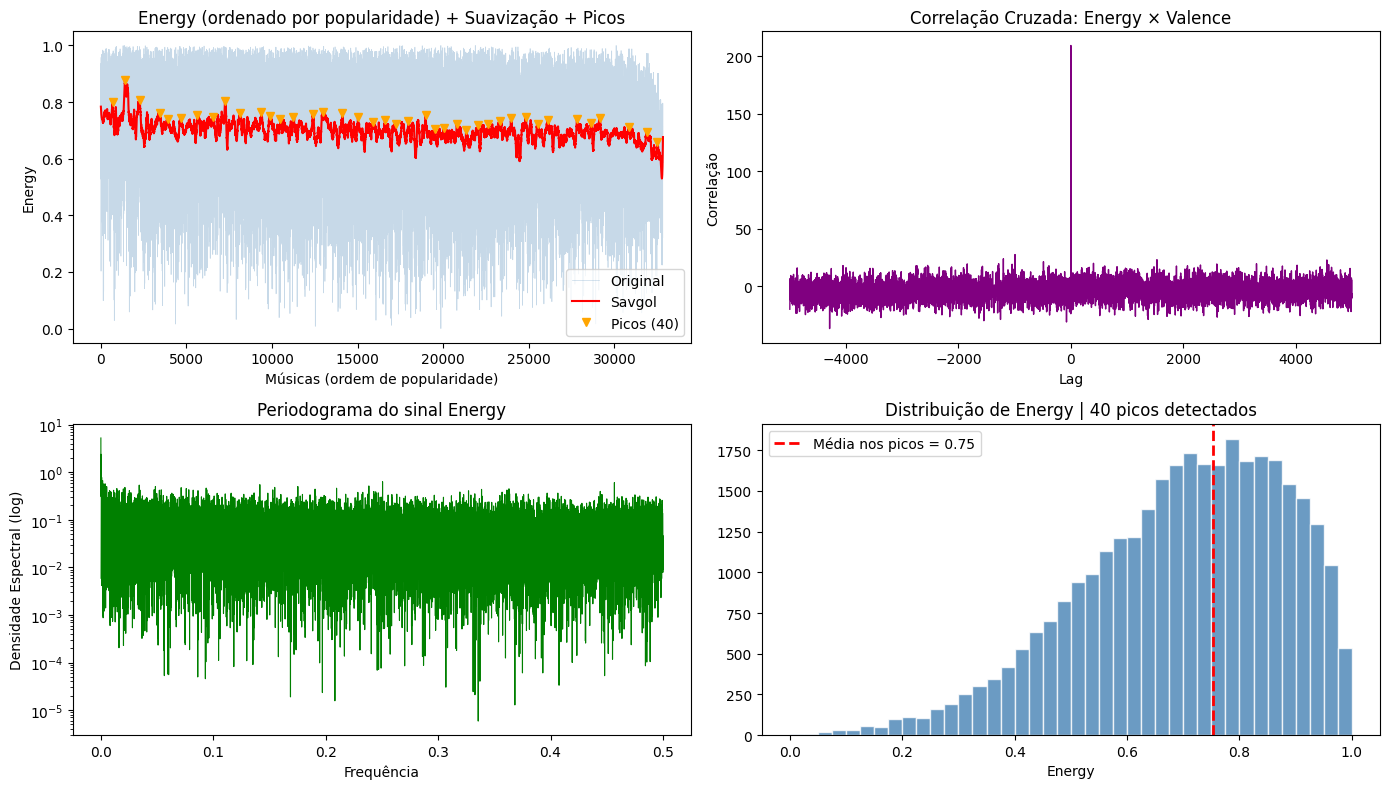

Picos detectados: 40
Popularidades nos picos: [0 0 0 2 3]


In [5]:
dados_sig = df[['popularity', 'energy', 'valence']].dropna().sort_values('popularity').reset_index(drop=True)

sinal_energy  = dados_sig['energy'].to_numpy()
sinal_valence = dados_sig['valence'].to_numpy()

sinal_suave = signal.savgol_filter(sinal_energy, window_length=201, polyorder=3)

picos, _ = signal.find_peaks(sinal_suave, distance=500, prominence=0.05)

correlacao = signal.correlate(sinal_energy - sinal_energy.mean(),
                               sinal_valence - sinal_valence.mean(), mode='full')
lags = signal.correlation_lags(len(sinal_energy), len(sinal_valence), mode='full')

freqs, potencia = signal.periodogram(sinal_energy)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(sinal_energy, alpha=0.3, color='steelblue', lw=0.5, label='Original')
axes[0, 0].plot(sinal_suave, color='red', lw=1.5, label='Savgol')
axes[0, 0].plot(picos, sinal_suave[picos], 'v', color='orange', ms=6, label=f'Picos ({len(picos)})')
axes[0, 0].set_title('Energy (ordenado por popularidade) + Suavização + Picos')
axes[0, 0].set_xlabel('Músicas (ordem de popularidade)')
axes[0, 0].set_ylabel('Energy')
axes[0, 0].legend()

n = len(correlacao)
centro = n // 2
janela = 5000
axes[0, 1].plot(lags[centro-janela:centro+janela], correlacao[centro-janela:centro+janela], color='purple', lw=1)
axes[0, 1].set_title('Correlação Cruzada: Energy × Valence')
axes[0, 1].set_xlabel('Lag')
axes[0, 1].set_ylabel('Correlação')

axes[1, 0].semilogy(freqs[1:], potencia[1:], color='green', lw=0.8)
axes[1, 0].set_title('Periodograma do sinal Energy')
axes[1, 0].set_xlabel('Frequência')
axes[1, 0].set_ylabel('Densidade Espectral (log)')

axes[1, 1].hist(sinal_energy, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(sinal_energy[picos].mean(), color='red', lw=2, linestyle='--',
                    label=f'Média nos picos = {sinal_energy[picos].mean():.2f}')
axes[1, 1].set_title(f'Distribuição de Energy | {len(picos)} picos detectados')
axes[1, 1].set_xlabel('Energy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Picos detectados: {len(picos)}")
print(f"Popularidades nos picos: {dados_sig['popularity'].iloc[picos].values[:5]}")

# Desafio: Construindo uma Matriz Esparsa de Similaridade Musical - (PONTO EXTRA)

Sistemas de recomendação frequentemente utilizam matrizes extremamente grandes e esparsas para representar relações entre itens. Neste exercício, utilize os atributos danceability, energy, valence e tempo para construir uma matriz de similaridade entre músicas e armazená-la utilizando estruturas do módulo scipy.sparse.

Selecione uma amostra de 1000 músicas, padronize os atributos e calcule uma matriz de similaridade baseada no produto matricial. Em seguida, mantenha apenas as conexões cuja similaridade seja superior a um valor definido por você (por exemplo, 2.0), substituindo os demais valores por zero. Converta a matriz resultante para o formato esparso CSR, analise a quantidade de elementos armazenados e compare o consumo de memória da representação densa com a representação esparsa.

Apresente visualizações que permitam compreender a estrutura da matriz e discuta as vantagens do uso de matrizes esparsas em aplicações de Ciência de Dados.

### Funções obrigatórias
sparse.csr_matrix()
### Funções sugeridas
stats.zscore()
np.count_nonzero()
### Visualizações obrigatórias
Heatmap de uma pequena região da matriz de similaridade.
Visualização da matriz esparsa utilizando: plt.spy()
Gráfico comparando quantidade de elementos totais e elementos armazenados.

Dimensão da matriz:        (1000, 1000)
Total de elementos:        1,000,000
Elementos não-zero:        140,994
Sparsidade:                85.90%
Memória densa:             7812.5 KB
Memória esparsa (CSR):     1656.2 KB
Redução de memória:        78.80%


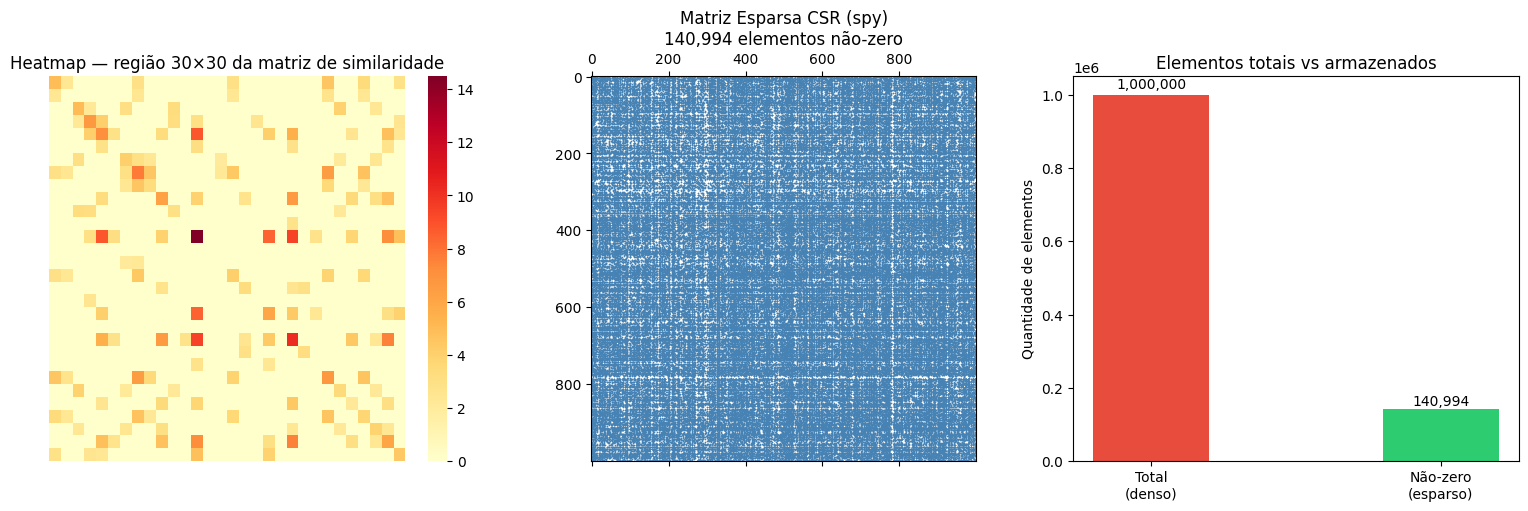


=== Discussão ===
Matrizes esparsas são vantajosas quando a maioria dos elementos é zero.
O formato CSR armazena apenas valores não-zero + índices, economizando memória.
Em sistemas de recomendação com milhões de usuários/itens, isso é essencial.
Neste caso: 85.90% dos elementos são zero — redução de 78.80% na memória.


In [6]:
from scipy import sparse

cols_esp = ['danceability', 'energy', 'valence', 'tempo']
amostra = df[cols_esp].dropna().sample(1000, random_state=42).to_numpy()

amostra_z = stats.zscore(amostra, axis=0)

sim_densa = amostra_z @ amostra_z.T

limiar = 2.0
sim_filtrada = np.where(sim_densa > limiar, sim_densa, 0.0)

sim_esparsa = sparse.csr_matrix(sim_filtrada)

total_elementos   = sim_densa.size
elementos_nao_zero = np.count_nonzero(sim_filtrada)
sparsidade = 1 - elementos_nao_zero / total_elementos

mem_densa   = sim_densa.nbytes
mem_esparsa = sim_esparsa.data.nbytes + sim_esparsa.indices.nbytes + sim_esparsa.indptr.nbytes

print(f"Dimensão da matriz:        {sim_densa.shape}")
print(f"Total de elementos:        {total_elementos:,}")
print(f"Elementos não-zero:        {elementos_nao_zero:,}")
print(f"Sparsidade:                {sparsidade:.2%}")
print(f"Memória densa:             {mem_densa/1024:.1f} KB")
print(f"Memória esparsa (CSR):     {mem_esparsa/1024:.1f} KB")
print(f"Redução de memória:        {(1 - mem_esparsa/mem_densa):.2%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(sim_filtrada[:30, :30], cmap='YlOrRd', ax=axes[0],
            xticklabels=False, yticklabels=False)
axes[0].set_title('Heatmap — região 30×30 da matriz de similaridade')

axes[1].spy(sim_esparsa, markersize=0.3, color='steelblue')
axes[1].set_title(f'Matriz Esparsa CSR (spy)\n{elementos_nao_zero:,} elementos não-zero')

categorias = ['Total\n(denso)', 'Não-zero\n(esparso)']
valores = [total_elementos, elementos_nao_zero]
cores = ['#e74c3c', '#2ecc71']
bars = axes[2].bar(categorias, valores, color=cores, width=0.4)
for bar, val in zip(bars, valores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)
axes[2].set_title('Elementos totais vs armazenados')
axes[2].set_ylabel('Quantidade de elementos')

plt.tight_layout()
plt.show()

print("""
=== Discussão ==="""
)
print("Matrizes esparsas são vantajosas quando a maioria dos elementos é zero.")
print("O formato CSR armazena apenas valores não-zero + índices, economizando memória.")
print("Em sistemas de recomendação com milhões de usuários/itens, isso é essencial.")
print(f"Neste caso: {sparsidade:.2%} dos elementos são zero — redução de {(1 - mem_esparsa/mem_densa):.2%} na memória.")